# Using Neurokit2 to process data

In [36]:
#%pip install neurokit2
import neurokit2 as nk
import pandas as pd

Processing data from the EmotiBit file

In [37]:
eda_file = r"engaged\2025-07-10_15-09-52-005859_EA.csv"

raw_data = pd.read_csv(eda_file)

## Data Selection and Prewview

Select a range

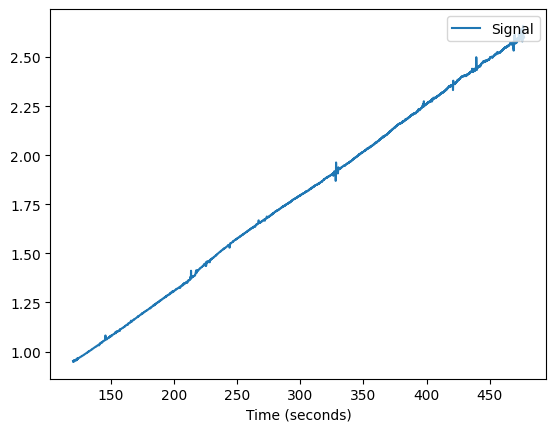

In [38]:
df_min = raw_data["LocalTimestamp"].min() + 120
df_max = raw_data["LocalTimestamp"].max() - 120
df = raw_data[(raw_data["LocalTimestamp"]>df_min) & (raw_data["LocalTimestamp"]<df_max)]
df_ea = df["EA"]

nk.signal_plot(df_ea, sampling_rate=15) # Check basic graph

Filters

In [39]:
from scipy.signal import butter, filtfilt

sample_rate_eda = 15

def low_pass_filter(data, cutoff_freq, sample_rate):
    nyquist = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

Applying a bandpass filter 0.1 - 5 Hz

In [40]:
df_ea_filtered = bandpass_filter(df_ea, lowcut=0.1, highcut=5, fs=sample_rate_eda)

Obtain basic EDA plot

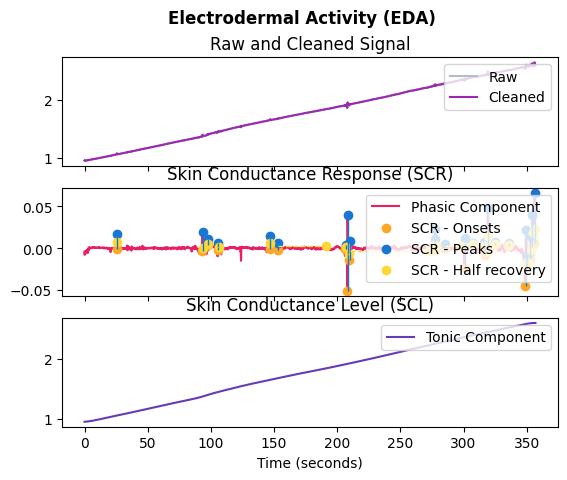

In [41]:
# raw eda signal
signals, info = nk.eda_process(df_ea, sampling_rate=15)

plt = nk.eda_plot(signals, info)

Filtered EDA

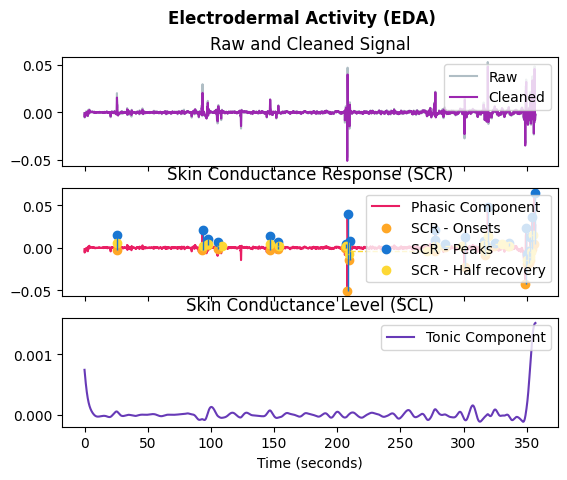

In [42]:
f_signals, f_info = nk.eda_process(df_ea_filtered, sampling_rate=15)
nk.eda_plot(f_signals, f_info)

## Analyze EDA data

The processing function does two important things for our purpose: Firstly, it cleans the signal. Secondly, it detects the location of 1) peak onsets, 2) peak amplitude, and 3) half-recovery time. Let’s extract these from the output.

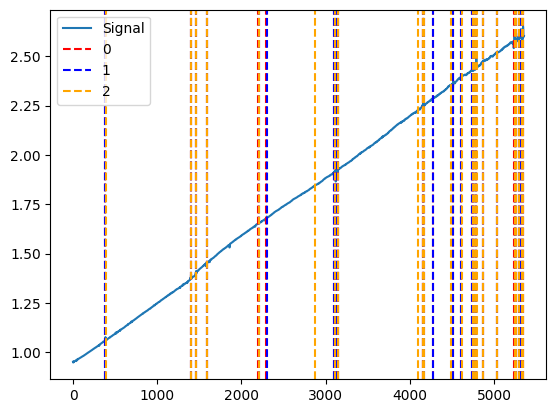

In [43]:
# Extract clean EDA and SCR features
cleaned = signals["EDA_Clean"]
features = [info["SCR_Onsets"], info["SCR_Peaks"], info["SCR_Recovery"]]

# Visualize SCR features in cleaned EDA signal
plot = nk.events_plot(features, cleaned, color=['red', 'blue', 'orange'])

In [44]:
epochs = nk.epochs_create(signals, events=1 ,sampling_rate=15)
nk.eda_eventrelated(epochs)

c:\Users\omshr\anaconda3\envs\cs328\lib\site-packages\neurokit2\epochs\eventrelated_utils.py:37: NeuroKitWarning: eda_eventrelated(): The duration of your epochs seems quite long. You might want to use eda_intervalrelated().
  warn(


,Label,Event_Onset,EDA_Peak_Amplitude,EDA_SCR,SCR_Peak_Amplitude,SCR_Peak_Amplitude_Time,SCR_RiseTime,SCR_RecoveryTime
1,1,2677,0.066563,1,0.005017,28.405306,0.333333,37.933333


In [45]:
nk.eda_intervalrelated(signals, sampling_rate=15)

,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,24.0,0.023274,0.484461,0.000002,0.000023,0.966702
